<a href="https://colab.research.google.com/github/paulaadel5/Video-Action-Recognition/blob/main/vit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Mount Google Drive

from google.colab import drive
drive.mount('/content/drive') # Import required libraries


import tensorflow as tf
from tensorflow.keras import layers, Model
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Hyperparameters


DATASET_PATH = "/content/drive/MyDrive/processed_data/frames"

IMG_SIZE = 224 #كل صوره 224*224
PATCH_SIZE = 32 #تتقسم كل مربع حجمه 32

EMBED_DIM = 128 #يتحول vector حجمه128
NUM_HEADS = 4 #عدد ال attention head
DEPTH = 2

BATCH_SIZE = 8 #عدد طبقات ال transfermer block
EPOCHS = 8

In [ ]:
# TRAIN DATASET
train_ds = tf.keras.utils.image_dataset_from_directory(
    f"{DATASET_PATH}/train",
    class_names=["cheating", "normal"],
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

# VALIDATION DATASET
val_ds = tf.keras.utils.image_dataset_from_directory(
    f"{DATASET_PATH}/val",
    class_names=["cheating", "normal"],
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

# TEST DATASET
test_ds = tf.keras.utils.image_dataset_from_directory(
    f"{DATASET_PATH}/test",
    class_names=["cheating", "normal"],
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False #مش هنغير تدريب الصور
)

Found 5165 files belonging to 2 classes.
Found 1086 files belonging to 2 classes.
Found 1173 files belonging to 2 classes.


In [ ]:
# Normalize images

normalization = layers.Rescaling(1./255)

In [ ]:
# Data augmentation


augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
])

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE   #كل batchب 3خطوات

train_ds = train_ds.map(
    lambda x, y: (
        augmentation(
            normalization(x),
            training=True
        ),
        y
    ),
    num_parallel_calls=AUTOTUNE
)

In [ ]:
# Apply preprocessing

val_ds   = val_ds.map(lambda x, y: (normalization(x), y))
test_ds  = test_ds.map(lambda x, y: (normalization(x), y))

In [ ]:
# Prefetch + Cache
train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE) #مش محتاج cache

In [ ]:
import os
import numpy as np

train_path = f"{DATASET_PATH}/train"

labels = [] #فيها كل ال lables اللي محتاج يتعلمها

# use only these classes
allowed_classes = ["cheating", "normal"]

for class_name in allowed_classes:

    class_folder = os.path.join(train_path, class_name)

    if os.path.isdir(class_folder):

        num_files = len(os.listdir(class_folder))

        labels.extend([class_name] * num_files)

In [ ]:
# convert labels to numeric
unique_classes = sorted(set(labels))

class_to_idx = {c:i for i,c in enumerate(unique_classes)}

labels_num = np.array([class_to_idx[l] for l in labels])

In [ ]:
# count samples
counts = np.bincount(labels_num)

print("Classes:", unique_classes)
print("Class distribution:", counts)

Classes: ['cheating', 'normal']
Class distribution: [4232  937]


In [ ]:
# compute weights
total = np.sum(counts)

class_weight = {
    i: total / (len(counts) * c)
    for i, c in enumerate(counts)
}

print("Class weights:", class_weight)

Class weights: {0: np.float64(0.6107041587901701), 1: np.float64(2.758271077908218)}


In [ ]:
# PATCH EMBEDDING #نقسمها الي اجزاء
class PatchEmbedding(layers.Layer):

    def __init__(self):
        super().__init__()

        self.proj = layers.Conv2D(
            filters=EMBED_DIM,
            kernel_size=PATCH_SIZE,
            strides=PATCH_SIZE
        )

    def call(self, x):

        x = self.proj(x)

        B = tf.shape(x)[0]

        x = tf.reshape(x, (B, -1, EMBED_DIM))

        return x

In [ ]:
#TRANSFORMER BLOCK
class TransformerBlock(layers.Layer):
    def __init__(self):
        super().__init__()

        self.norm1 = layers.LayerNormalization()

        self.attn = layers.MultiHeadAttention(
            num_heads=NUM_HEADS,
            key_dim=EMBED_DIM // NUM_HEADS
        )

        self.norm2 = layers.LayerNormalization()

        self.mlp = tf.keras.Sequential([
            layers.Dense(EMBED_DIM * 4, activation=tf.nn.gelu),
            layers.Dropout(0.3),
            layers.Dense(EMBED_DIM)
        ])

    def call(self, x):

        x = x + self.attn(self.norm1(x), self.norm1(x))

        x = x + self.mlp(self.norm2(x))

        return x

In [ ]:
class VisionTransformer(tf.keras.Model):

    def __init__(self):
        super().__init__()


        # Patch Embedding layer
        self.patch_embed = PatchEmbedding()


        # Positional Embedding (49 patches)
        num_patches = (IMG_SIZE // PATCH_SIZE) ** 2
        self.pos_embed = self.add_weight(
            shape=(1, num_patches, EMBED_DIM),
            initializer="random_normal",
            trainable=True
        )


        # Transformer blocks
        self.blocks = [TransformerBlock() for _ in range(DEPTH)]


        # Normalization layer
        self.norm = tf.keras.layers.LayerNormalization()

        # Dropout for regularization
        self.dropout = tf.keras.layers.Dropout(0.5)
        # FIX: Final classification head
        # Binary classification => 2 classes + softmax

        self.head = tf.keras.layers.Dense(2, activation="softmax")

    def call(self, x):

        # Step 1: Patch embedding
        x = self.patch_embed(x)


        # Step 2: Add positional embedding
        x = x + self.pos_embed


        # Step 3: Transformer blocks
        for block in self.blocks:
            x = block(x)


        # Step 4: Normalization
        x = self.norm(x)


        # Step 5: Global average pooling over patches
        x = tf.reduce_mean(x, axis=1)


        # Step 6: Dropout
        x = self.dropout(x)


        # Step 7: Classification head
        output = self.head(x)

        return output

In [ ]:
# Focal Loss

def focal_loss(alpha=0.25, gamma=2.0):

    def loss(y_true, y_pred):

        y_true = tf.one_hot(
            tf.cast(y_true, tf.int32),
            depth=2  # Corrected for categorical crossentropy.
        )

        ce = tf.keras.losses.categorical_crossentropy(
            y_true,
            y_pred,
            from_logits=False #حساب ال cross entropt
        )

        pt = tf.reduce_sum(
            y_true * y_pred, # Corrected as y_pred are already softmax activated
            axis=-1
        )

        return alpha * (1 - pt) ** gamma * ce

    return loss


In [ ]:
#class info

class_names = unique_classes
NUM_CLASSES = len(class_names)

print("Classes:", class_names)
print("NUM_CLASSES:", NUM_CLASSES)

#BUILD MODEL
model = VisionTransformer()

dummy = tf.random.normal((1, 224, 224, 3))
model(dummy)

model.summary()

Classes: ['cheating', 'normal']
NUM_CLASSES: 2


Model: "vision_transformer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ patch_embedding                 │ ?                      │       393,344 │
│ (PatchEmbedding)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ ?                      │       198,272 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ ?                      │       198,272 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_4           │ (1, 49, 128)           │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (1, 2)                 │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 796,674 (3.04 MB)

 Trainable params: 796,674 (3.04 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#VALIDATION BEFORE TRAINING
# Sanity check before training

for images, labels in val_ds.take(1):

    preds = model(images, training=False)

    preds = tf.argmax(preds, axis=1)

    print("True:", labels.numpy()[:10])
    print("Pred:", preds.numpy()[:10])


True: [0 0 0 0 0 0 0 1]
Pred: [1 1 1 1 1 1 1 1]


In [ ]:
for x, y in train_ds.take(1):
    print("X shape:", x.shape)
    print("Y shape:", y.shape)

X shape: (8, 224, 224, 3)
Y shape: (8,)


In [ ]:
dummy = tf.random.normal((1, 224, 224, 3))
out = model(dummy)

print("Output shape:", out.shape)

Output shape: (1, 2)


In [ ]:
import tensorflow as tf

tf.config.optimizer.set_jit(False)


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=focal_loss(),
    metrics=["accuracy"]
)

In [ ]:
for x, y in train_ds.take(1):
    print(y)

tf.Tensor([0 1 0 0 0 0 0 0], shape=(8,), dtype=int32)


In [ ]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    factor=0.5,
    min_lr=1e-6
)

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr])

Epoch 1/8
646/646 ━━━━━━━━━━━━━━━━━━━━ 2833s 4s/step - accuracy: 0.8054 - loss: 0.0349 - val_accuracy: 0.7744 - val_loss: 0.0366 - learning_rate: 1.0000e-05
Epoch 2/8
646/646 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8137 - loss: 0.0325 - val_accuracy: 0.7744 - val_loss: 0.0378 - learning_rate: 1.0000e-05
Epoch 3/8
646/646 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8136 - loss: 0.0322 - val_accuracy: 0.7744 - val_loss: 0.0402 - learning_rate: 1.0000e-05
Epoch 4/8
646/646 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8190 - loss: 0.0315 - val_accuracy: 0.7744 - val_loss: 0.0374 - learning_rate: 5.0000e-06


In [ ]:
# VALIDATION AFTER TRAINING

val_true, val_pred = [], []

for images, labels in val_ds:

    preds = model(images, training=False)

    preds = tf.argmax(preds, axis=1)

    val_true.extend(labels.numpy())
    val_pred.extend(preds.numpy())

val_true = np.array(val_true)
val_pred = np.array(val_pred)

In [ ]:
from sklearn.metrics import accuracy_score

# Basic accuracy


acc = accuracy_score(y_true, y_pred)
print("Test Accuracy:", acc)

Test Accuracy: 0.7962489343563512


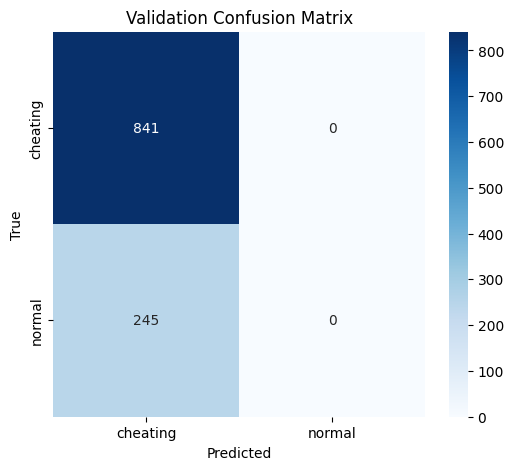

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


# Compute confusion matrix

cm = confusion_matrix(val_true, val_pred)

#plot
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [ ]:
from sklearn.metrics import classification_report, accuracy_score

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.80      1.00      0.89       934
           1       0.00      0.00      0.00       239

    accuracy                           0.80      1173
   macro avg       0.40      0.50      0.44      1173
weighted avg       0.63      0.80      0.71      1173



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import numpy as np

y_true = np.array(y_true)
y_pred = np.array(y_pred)

wrong_idx = np.where(y_true != y_pred)[0]

print("Total errors:", len(wrong_idx))
print("Sample wrong predictions:")
print(list(zip(y_true[wrong_idx][:10], y_pred[wrong_idx][:10])))

Total errors: 239
Sample wrong predictions:
[(np.int32(1), np.int64(0)), (np.int32(1), np.int64(0)), (np.int32(1), np.int64(0)), (np.int32(1), np.int64(0)), (np.int32(1), np.int64(0)), (np.int32(1), np.int64(0)), (np.int32(1), np.int64(0)), (np.int32(1), np.int64(0)), (np.int32(1), np.int64(0)), (np.int32(1), np.int64(0))]


In [ ]:
model.save("/content/drive/MyDrive/vit_model.keras")

Report on Model 5
Transformers Attention + Vision Transformer (ViT)
Project Introduction

The main goal of the Cheating Detection System project is to detect cheating behaviors inside examination halls using artificial intelligence and video analysis.

Model 5 is based on:

Transformers
Attention Mechanism
Vision Transformer (ViT)

These are among the most advanced deep learning techniques used for image and video understanding, especially for analyzing human behavior and detecting suspicious actions.

General Idea of the Model

The model does not simply look at the whole image as one object. Instead, it:

Focuses on important regions in the image
Understands relationships between movements
Determines whether the behavior is normal or suspicious

Examples of suspicious behaviors:

Looking repeatedly at another paper
Using a mobile phone
Exchanging papers
Continuous head turning
Whispering

All these actions are analyzed using the Attention Mechanism.

Why Did We Choose Vision Transformer (ViT)?

The Vision Transformer was selected because:

1. Strong Understanding of Image Relationships

Unlike traditional CNNs that focus mainly on nearby pixels, ViT understands global relationships across the entire image.

2. Suitable for Complex Behavior Analysis

Cheating detection depends on multiple factors such as:

Eye direction
Hand movement
Head position
Object appearance (phone or paper)

Transformers are excellent at understanding such relationships.

3. High Accuracy

ViT achieves strong performance in:

Image classification
Action recognition
Video understanding
4. Easy to Scale and Improve

The model can later be extended to:

Detect more cheating behaviors
Improve accuracy
Integrate with other models inside the Ensemble System

Model Components Explanation
1. Input Video Frames

The input to the model is a video.

The video is divided into:

Multiple frames
Each frame is treated as a separate image

2. Preprocessing

In this stage, frames are prepared before entering the model.

This includes:

Resize

All images are resized to a fixed dimension such as:

224 × 224
Normalization

Pixel values are normalized to improve training stability.

Data Augmentation

Extra transformations are applied such as:

Horizontal flipping
Rotation
Brightness adjustment

This helps reduce overfitting.

3. Splitting the Image into Patches

This is the key idea behind ViT.

Instead of processing the image as one block, the image is divided into:

Image Patches

For example:

A 224 × 224 image
Split into 16 × 16 patches

Each patch becomes a small piece of the image.

Similar to NLP where a sentence is divided into words, ViT divides images into patches.

4. Patch Embedding

Each patch is converted into:

A Numerical Vector

This allows the Transformer to process image data mathematically.

As a result:

The image becomes a sequence of vectors.

5. Positional Encoding

Transformers do not naturally understand the position of image patches.

Therefore, positional information is added so the model can understand:

Where the face is located
Where the hands are
Where the phone appears

This helps preserve spatial relationships.

6. Attention Mechanism

This is the most important part of the model.

What is Attention?

Attention allows the model to:

Focus on important regions
Ignore irrelevant background information

For example:
If a student is looking toward another paper, the model focuses on:

Eyes
Head direction
Hand movement

Instead of walls or background objects

Self-Attention

Inside the Transformer, there is:

Self-Attention

This enables every image patch to:

Interact with other patches
Learn relationships between them

For example:

Hand movement may relate to head direction
Phone appearance may relate to suspicious posture

This helps the model understand cheating behaviors more accurately.

7. Transformer Encoder

The Transformer Encoder contains multiple repeated layers including:

Multi-Head Attention
Feed Forward Networks
Normalization
Residual Connections

Its purpose is to:

Extract powerful features
Learn complex visual relationships

8. Feature Extraction

After processing through the Transformer:

Deep Features are extracted

These features represent:

Suspicious movements
Repeated head turning
Mobile phone usage
Paper exchange

9. Classification Layer

Finally, the model classifies the behavior into:

Cheat
or
No Cheat

Input Exam Video
        ↓
Frame Extraction
        ↓
Dataset Organization
(train / validation / test)
        ↓
Image Preprocessing
- Resize to 224×224
- Normalize pixel values
        ↓
Data Augmentation
- Random Flip
- Rotation
- Zoom
- Contrast Adjustment
- Brightness Adjustment
        ↓
Patch Embedding
- Split image into 32×32 patches
- Convert patches into embeddings
        ↓
Positional Embedding
- Add spatial position information
        ↓
Transformer Encoder Blocks
- Multi-Head Self Attention
- Layer Normalization
- Feed Forward Network
- Residual Connections
        ↓
Feature Aggregation
(Global Average Pooling)
        ↓
Dropout Layer
(Reduce Overfitting)
        ↓
Classification Head
(Dense + Softmax)
        ↓
Output Prediction
- Cheating
- Normal
        ↓
Model Evaluation
- Accuracy
- Confusion Matrix
- Classification Report
        ↓
Final Cheating Detection Decision